In [5]:
import joblib

X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")

y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

In [7]:
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import time

In [2]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    # Training
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Prediction
    start_predict = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_predict

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1 = report["1"]["f1-score"]

    # Results
    print("=" * 50)
    print(f"Model: {model.__class__.__name__}")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print(f"Training Time   : {train_time:.4f} seconds")
    print(f"Prediction Time : {predict_time:.4f} seconds")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Normal", "Attack"]
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Attack"]
    )

    disp.plot()
    plt.show()

    return {
        "model": model.__class__.__name__,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "train_time": train_time,
        "predict_time": predict_time
    }

In [3]:
tree = DecisionTreeClassifier(
    random_state=42
)

Model: DecisionTreeClassifier
Accuracy : 0.8015
Precision: 0.9665
Recall   : 0.6746
F1-Score : 0.7946
Training Time   : 4.4197 seconds
Prediction Time : 0.0159 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.69      0.97      0.81      9711
      Attack       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



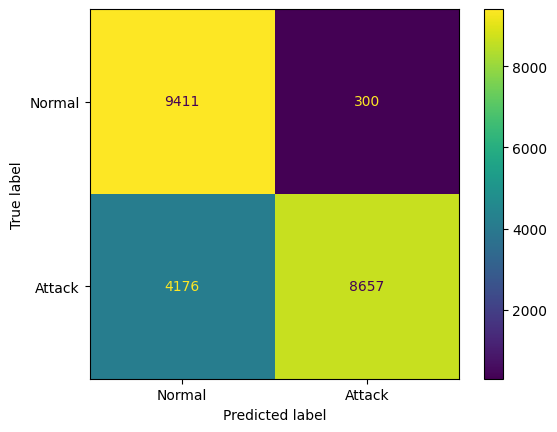

In [8]:
tree_result = evaluate_model(
    tree,
    X_train,
    y_train,
    X_test,
    y_test
)

In [9]:
print("Tree depth:", tree.get_depth())
print("Number of leaves:", tree.get_n_leaves())

Tree depth: 21
Number of leaves: 231
